# Bin-to-Cell Benchmark

**Purpose.** Compare Raw and REVISE sp-SVC reconstruction quality for the size-8 bin-to-cell assignment using PCC, SSIM, and MSE.

**Inputs.** Use the Sim2Real-ST segmentation H5AD inputs for parts 1–3 and the corresponding size-8 raw and REVISE metric CSV files under the historical segmentation result tree.

### Two ways to obtain the analysis inputs

1. **Reconstruct locally.** Download the Sim2Real-ST inputs and run the raw and REVISE bin-to-cell workflows for size 8, writing their metric tables to the configured result tree.
2. **Start from released results.** Download [`Sim2Real-ST.zip` and `Result.zip`](https://zenodo.org/records/17705737), then place the extracted files under the raw-data and result directories declared in the configuration section.

Both routes must provide the size-8 raw and REVISE metric tables before analysis begins.

After completing either path, run this notebook from top to bottom.

## 1. Configuration

Define repository paths, the size-8 bin-to-cell case, methods, metrics, and gene-selection settings.

In [1]:
# [CONFIG] Repository and output paths
import os

source_path = "../.."
output_dir = f"{source_path}/output/bin2cell"
os.makedirs(output_dir, exist_ok=True)

In [2]:
# [CONFIG] Bin-to-cell benchmark settings
task = "bin2cell"
result_path = f"{source_path}/results/seg"
sim2real_data_path = f"{source_path}/raw_data/Sim2Real-ST/seg"

methods = ["raw", "sp_SVC"]
parts = ["part3", "part1", "part2"]
metrics = ["PCC", "SSIM", "MSE"]
spot_sizes = [8]
gene_type = "All"
gene_num = 50

save_dir = f"{output_dir}/{gene_type}_mean"
os.makedirs(save_dir, exist_ok=True)

import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.useafm"] = False

## 2. Input, metric, and plotting helpers

Define all loaders and plotting helpers locally so this notebook has no dependency on the segmentation notebook.

In [3]:
# [DEFINE] Shared gene-selection and metric-loading helpers
import os
import pandas as pd
import scanpy as sc
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

def get_genes(result_path, data_path, part, spot_size, method, gene_type = "HVG", gene_num = 50, test_genes = None): 
    # Select HVG, HEG, or all genes.
    spot_path = os.path.join(data_path, f"{part}", f"spot_{spot_size}")
    save_path = os.path.join(result_path, part, f"{spot_size}_{method}", "select_gene")
    os.makedirs(save_path, exist_ok=True)

    gene_file = f"{save_path}/{gene_type}_genes_{gene_num}.txt"
    if os.path.exists(gene_file):
        # print(f"Find {gene_type} genes in {gene_file}")
        with open(gene_file, "r") as f:
            genes = f.read().splitlines()
        return genes

    st_path = f"{spot_path}/xenium_spot.h5ad"
    adata = sc.read(st_path)
    if test_genes is not None:
        overlap_genes = [gene for gene in test_genes if gene in adata.var_names]
        adata = adata[:, overlap_genes]
    
    if gene_type == "HVG":
        sc.pp.filter_genes(adata, min_cells=1)
        sc.pp.normalize_total(adata, target_sum=1e4)
        sc.pp.highly_variable_genes(adata, flavor='seurat_v3', n_top_genes=gene_num)
        genes = adata.var[adata.var['highly_variable']].index.tolist()
    elif gene_type == "HEG":
        adata.var['sum'] = adata.X.toarray().sum(axis=0)
        adata.var.sort_values('sum', ascending=True, inplace=True)
        genes = adata.var.head(gene_num).index.tolist()
    else:
        genes = adata.var_names
    
    with open(gene_file, "w") as f:
        f.write("\n".join(genes))
    # print(f"Save {gene_type} genes to {gene_file}")

    return genes

/Users/stephen/miniconda3/envs/python3.10/lib/python3.10/site-packages/torch/cuda/__init__.py:58: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [4]:
# [DEFINE] Bin-to-cell metric loading and plotting helpers
def get_merge_df(result_path, data_path, parts, metric, methods, gene_type, gene_num):
    merge_df = pd.DataFrame()
    spot_size = 8
    for part in parts:
        for method in methods:
            if method == "raw":
                metric_file = f"{result_path}/{part}/spot_{spot_size}/raw_metrics_normalized.csv"
            elif method == "sp_SVC":
                metric_file = f"{result_path}/{part}/spot_{spot_size}/metrics_normalized.csv"
            
            # Load the metric table.
            df_metric = pd.read_csv(metric_file, index_col=0)
            df_metric.set_index('Gene', inplace=True)
            
            # Select the configured genes.
            genes = get_genes(result_path, data_path, part, spot_size, method, 
                            gene_type=gene_type, gene_num=gene_num, test_genes=df_metric.index)
            df_metric = df_metric.loc[genes]
            
            # Store values in long form for plotting.
            temp_df = pd.DataFrame({
                'Method': method,
                'Value': df_metric[metric].values,
                'Spot_size': spot_size,
                'Part': part,
                'Metric': metric,
            })
            
            merge_df = pd.concat([merge_df, temp_df])
    
    merge_df.reset_index(drop=True, inplace=True)
    return merge_df


def plot_comp_seg(merge_df, metric, ax):
    custom_palette = {
        "raw": '#80a9c8',
        "sp_SVC": '#e89786',
    }
    
    sns.boxplot(
        data=merge_df,
        x='Part',
        y='Value',
        hue='Method',
        palette=custom_palette,
        width=0.4,
        fliersize=2,
        showfliers=False,
        ax=ax
    )
    
    ax.set_ylabel(metric, fontsize=10)
    ax.xaxis.set_visible(False)

    if metric == "PCC":
        ax.set_ylim(0.2, 1.02)
    elif metric == "SSIM":
        ax.set_ylim(0.0, 1.02)
    elif metric == "MSE":
        ax.set_ylim(1e-5, 0.01)
        ax.set_yscale('log')

    if ax.get_legend() is not None:
        ax.legend_.remove()
    ax.set_aspect('auto')

## 3. Mean metrics

Compute and save mean PCC, SSIM, and MSE values for the size-8 bin-to-cell case.

In [5]:
# [RUN] Compute and save bin-to-cell mean metrics
merge_df = pd.DataFrame()
spot_sizes = [8]
for part in tqdm(parts, desc="parts"):
    for spot_size in tqdm(spot_sizes, desc="spot_sizes"): 
        merge_df = pd.DataFrame() 
        for method in methods:
            if method == "raw":
                metric_file = f"{result_path}/{part}/spot_{spot_size}/raw_metrics_normalized.csv"
            elif method == "sp_SVC":
                metric_file = f"{result_path}/{part}/spot_{spot_size}/metrics_normalized.csv"
            df = pd.read_csv(metric_file, index_col=0)
            df.set_index('Gene', inplace=True)
            genes = get_genes(result_path, sim2real_data_path, part, spot_size, method, gene_type = gene_type, gene_num = gene_num, test_genes = df.index)
            df = df.loc[genes]
            
            df = df[metrics].mean(axis=0)
        
            merge_df = pd.concat([merge_df, df], axis=1)
        merge_df.reset_index(drop=True, inplace=True)
        merge_df.index = metrics
        merge_df.columns = methods
        merge_df.T.to_csv(f"{save_dir}/{part}_{spot_size}_{gene_type}_{gene_num}.csv")

print(f"Saved final bin-to-cell metric tables to {save_dir} !")


parts: 100%|██████████| 3/3 [00:11<00:00,  3.86s/it]

Saved final bin-to-cell metric tables to ../../output/bin2cell/All_mean !


## 4. Comparison plots

Visualize the per-gene metric distributions across parts for Raw and REVISE sp-SVC.

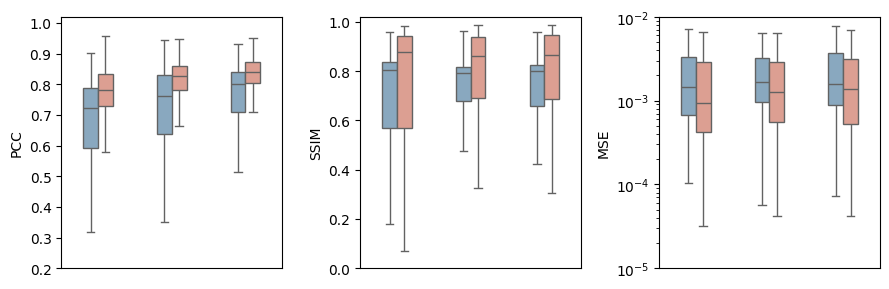

Saved final bin-to-cell PDF plot to ../../output/bin2cell !


In [6]:
# [RUN] Plot the bin-to-cell comparison
fig, axes = plt.subplots(1, 3, figsize=(9, 3))

for j, metric in enumerate(metrics):
    # Load the complete bin-to-cell comparison.
    merge_df = get_merge_df(result_path, sim2real_data_path, parts, metric, methods=methods, 
                           gene_type=gene_type, gene_num=gene_num)
    
    ax = axes[j]
    plot_comp_seg(merge_df, metric, ax)

plt.tight_layout()
plt.savefig(f"{output_dir}/{task}_{gene_type}_{gene_num}.pdf", dpi=300)
plt.show()

print(f"Saved final bin-to-cell PDF plot to {output_dir} !")

## 5. Outputs

Mean metric tables are written under `output/bin2cell/All_mean/`, and the comparison figure is written under `output/bin2cell/`. Displayed outputs are preserved historical snapshots and may show the former combined output directory; rerunning the notebook writes to the paths configured above.